Import data et packages
---

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yfinance as yf
import time

start = "2010-01-01"
end = time.strftime("%Y-%m-%d") 

cuivre = yf.download("HG=F", start=start, end=end)
oil = yf.download("CL=F", start=start, end=end)
ble = yf.download("ZC=F", start=start, end=end)
data = pd.concat([cuivre['Close'], oil['Close'], ble['Close']], axis=1)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


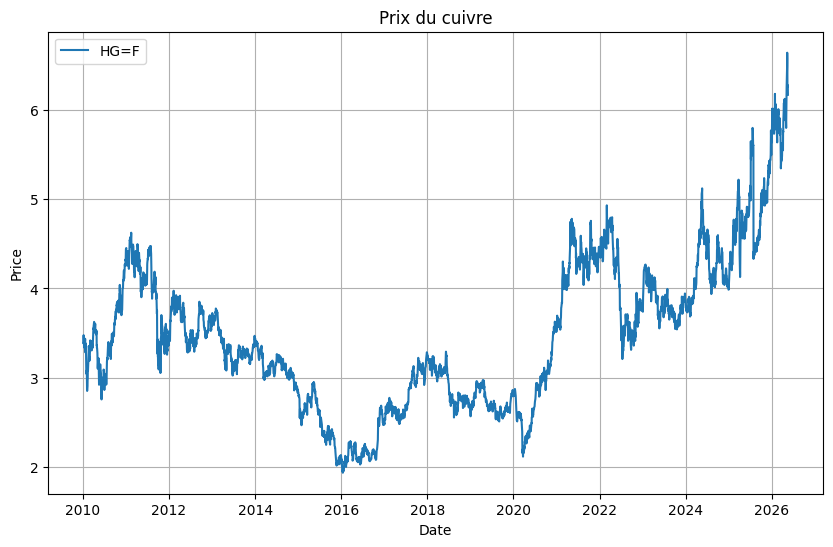

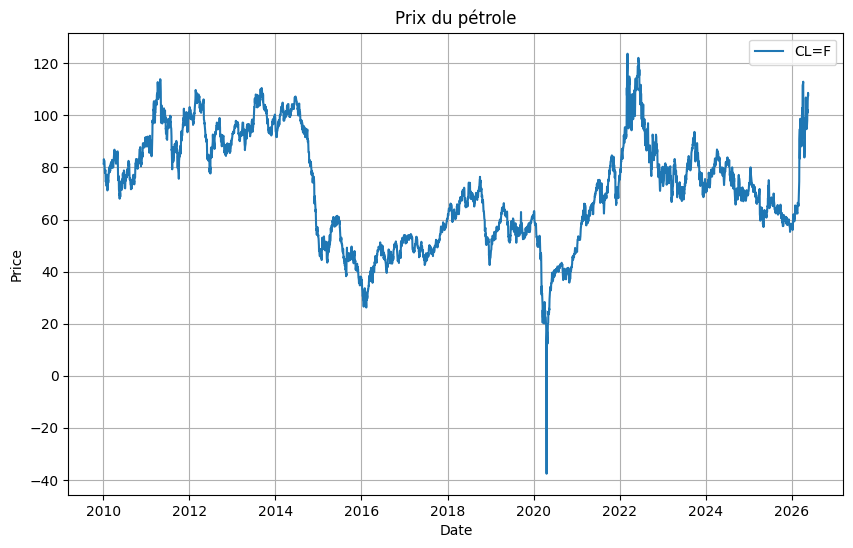

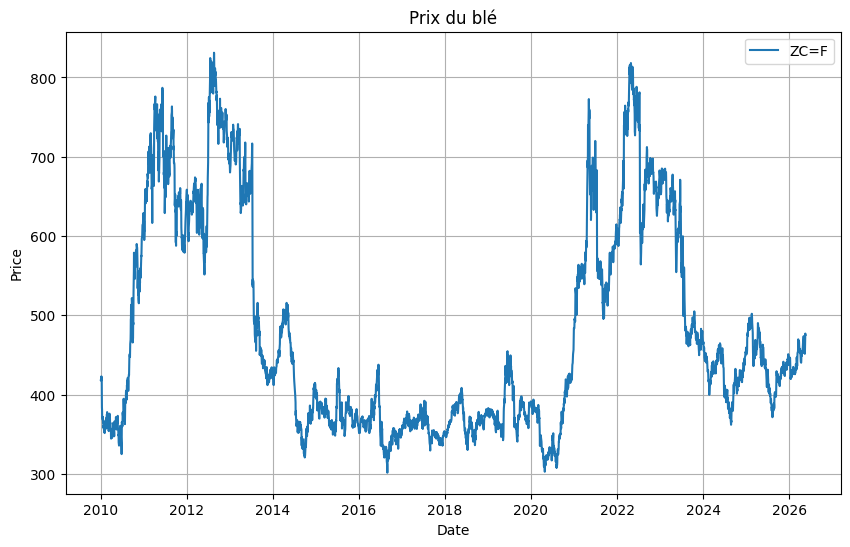

In [28]:
def show_plot(data, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend(data.columns)
    plt.grid()
    plt.show()

show_plot(cuivre['Close'], 'Prix du cuivre')
show_plot(oil['Close'], 'Prix du pétrole')
show_plot(ble['Close'], 'Prix du blé')

/Users/warrengallon/.pyenv/versions/3.11.8/lib/python3.11/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Users/warrengallon/.pyenv/versions/3.11.8/lib/python3.11/site-packages/matplotlib/cbook.py:1355: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


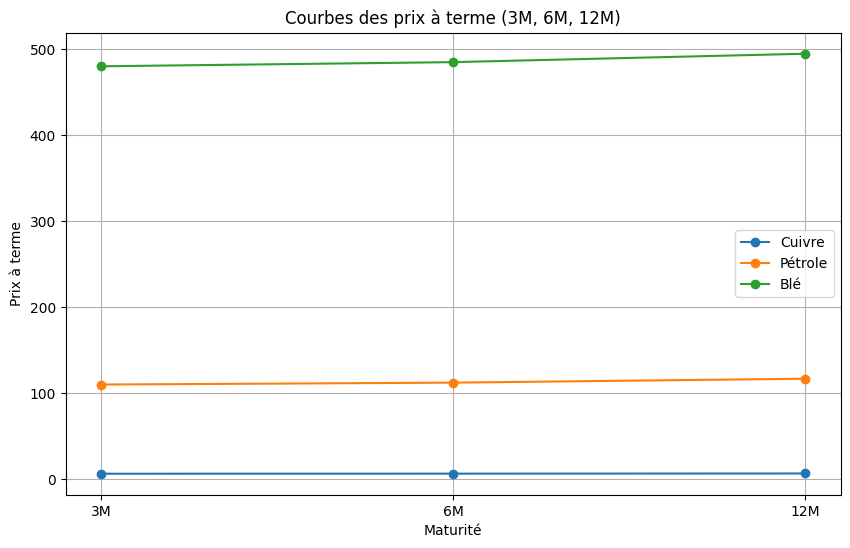

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def forward3M(r, u, y, S0):
    T = 3 / 12
    return S0 * np.exp((r + u - y) * T)

def forward6M(r, u, y, S0):
    T = 6 / 12
    return S0 * np.exp((r + u - y) * T)

def forward12M(r, u, y, S0):
    T = 12 / 12
    return S0 * np.exp((r + u - y) * T)

r = 0.02 

u_cuivre = 0.05
y_cuivre = 0.01
S0_cuivre = cuivre['Close'].iloc[-1] 

u_oil = 0.08
y_oil = 0.02
S0_oil = oil['Close'].iloc[-1] 

u_ble = 0.03
y_ble = 0.01
S0_ble = ble['Close'].iloc[-1]  

data_forward = pd.DataFrame({
    '3M': [
        forward3M(r, u_cuivre, y_cuivre, S0_cuivre),
        forward3M(r, u_oil, y_oil, S0_oil),
        forward3M(r, u_ble, y_ble, S0_ble)
    ],
    '6M': [
        forward6M(r, u_cuivre, y_cuivre, S0_cuivre),
        forward6M(r, u_oil, y_oil, S0_oil),
        forward6M(r, u_ble, y_ble, S0_ble)
    ],
    '12M': [
        forward12M(r, u_cuivre, y_cuivre, S0_cuivre),
        forward12M(r, u_oil, y_oil, S0_oil),
        forward12M(r, u_ble, y_ble, S0_ble)
    ]
}, index=['Cuivre', 'Pétrole', 'Blé'])

plt.figure(figsize=(10, 6))
for sous_jacent in data_forward.index:
    plt.plot(data_forward.columns, data_forward.loc[sous_jacent], marker='o', label=sous_jacent)

plt.title('Courbes des prix à terme (3M, 6M, 12M)')
plt.xlabel('Maturité')
plt.ylabel('Prix à terme')
plt.legend()
plt.grid()
plt.show()

In [29]:
import pandas as pd
import numpy as np

def generate_daily_parameters(start, end):
    np.random.seed(42) 
    dates = pd.date_range(start=start, end=end, freq='D')
    r = np.random.uniform(0.01, 0.05, len(dates))
    u = np.random.uniform(0.01, 0.05, len(dates))  
    y = np.random.uniform(0.01, 0.05, len(dates))  
    return pd.DataFrame({'Date': dates, 'r': r, 'u': u, 'y': y}).set_index('Date')

start = start
end = end
daily_parameters = generate_daily_parameters(start, end)

daily_parameters.head()

,r,u,y
Date,,,
2010-01-01,0.024982,0.015722,0.020310
2010-01-02,0.048029,0.010561,0.040072
2010-01-03,0.039280,0.032674,0.013799
2010-01-04,0.033946,0.047291,0.022831
2010-01-05,0.016241,0.036638,0.025486


In [ ]:
data_with_parameters = data.join(daily_parameters, how='inner')
data_with_parameters.head()

,HG=F,CL=F,ZC=F,r,u,y
Date,,,,,,
2010-01-04,3.3880,81.510002,418.50,0.033946,0.047291,0.022831
2010-01-05,3.3960,81.769997,418.75,0.016241,0.036638,0.025486
2010-01-06,3.4775,83.180000,421.75,0.016240,0.042906,0.034904
2010-01-07,3.4115,82.660004,417.50,0.012323,0.010531,0.016325
2010-01-08,3.3880,82.750000,423.00,0.044647,0.031681,0.044424


In [ ]:
data_with_parameters['Forward_3M_Cuivre'] = forward3M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['HG=F'])
data_with_parameters['Forward_6M_Cuivre'] = forward6M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['HG=F'])
data_with_parameters['Forward_12M_Cuivre'] = forward12M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['HG=F'])
data_with_parameters['Forward_3M_Oil'] = forward3M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['CL=F'])
data_with_parameters['Forward_6M_Oil'] = forward6M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['CL=F'])
data_with_parameters['Forward_12M_Oil'] = forward12M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['CL=F'])
data_with_parameters['Forward_3M_Ble'] = forward3M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['ZC=F'])
data_with_parameters['Forward_6M_Ble'] = forward6M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['ZC=F'])
data_with_parameters['Forward_12M_Ble'] = forward12M(data_with_parameters['r'], data_with_parameters['u'], data_with_parameters['y'], data_with_parameters['ZC=F'])
data_with_parameters.head()

,HG=F,CL=F,ZC=F,r,u,y,Forward_3M_Cuivre,Forward_6M_Cuivre,Forward_12M_Cuivre,Forward_3M_Oil,Forward_6M_Oil,Forward_12M_Oil,Forward_3M_Ble,Forward_6M_Ble,Forward_12M_Ble
Date,,,,,,,,,,,,,,,
2010-01-04,3.3880,81.510002,418.50,0.033946,0.047291,0.022831,3.437833,3.488399,3.591774,82.708911,83.925454,86.412486,424.655605,430.901751,443.671014
2010-01-05,3.3960,81.769997,418.75,0.016241,0.036638,0.025486,3.419336,3.442832,3.490310,82.331888,82.897640,84.040834,421.627485,424.524743,430.379122
2010-01-06,3.4775,83.180000,421.75,0.016240,0.042906,0.034904,3.498640,3.519908,3.562833,83.685650,84.194374,85.221118,424.313812,426.893209,432.099138
2010-01-07,3.4115,82.660004,417.50,0.012323,0.010531,0.016325,3.417073,3.422656,3.433848,82.795042,82.930300,83.201480,418.182051,418.865216,420.234896
2010-01-08,3.3880,82.750000,423.00,0.044647,0.031681,0.044424,3.415130,3.442478,3.497832,83.412642,84.080591,85.432577,426.387283,429.801691,436.712750
